In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
arquivo = pd.ExcelFile('[FM2S]Lista_Exercícios_1.xlsx')
print(arquivo.sheet_names)

['01.Transporte_Mercadorias', '02.Clínica', '03.Atendimento_UPA', '04a.Manutenção', '04b.Manutenção', '05.Acidentes', '06.Vendas']


In [10]:
arquivo = '[FM2S]Lista_Exercícios_1.xlsx'
aba = '04a.Manutenção'

df = pd.read_excel(arquivo, sheet_name=aba)
df.head()

,Data,Código,Descrição,Localização,Horas Paradas por Problemas Elétricos_1,Horas Paradas por Problemas Elétricos_2,Horas Paradas por Problemas Elétricos_3,Horas Paradas por Problemas Elétricos_4,Horas Paradas por Problemas Mecânicos 1,Horas Paradas por Problemas Mecânicos 2,Horas Paradas por Problemas Mecânicos 3,Horas Paradas por Problemas Mecânicos 4,Horas Paradas por Problemas de Molde tipo 1,Horas Paradas por Problemas de Molde tipo 2,Horas Paradas por Problemas de Molde tipo 3,Horas Paradas por Problemas de Molde tipo 4,Tot,TotPE,TotMec,TotMol
0,jan./2014,1-INJ-001,Romi 1100,Injeção,6.0,1.0,0.0,6,0,0,0,0,0.00,0.0,0.0,0.0,13.00,13.0,0.00,0.00
1,jan./2014,1-INJ-023,Sandretto 450,Injeção,0.0,0.0,1.0,0,0,0,5.5,0,12.00,12.0,11.0,12.0,53.50,1.0,5.50,47.00
2,jan./2014,1-INJ-024,Sandretto 450,Injeção,0.0,0.0,1.0,0,0,0,0,0,0.00,0.0,0.0,0.0,1.00,1.0,0.00,0.00
3,jan./2014,1-INJ-025,Demag,Injeção,0.0,0.0,1.0,0,0,0,0,0,10.18,3.0,3.5,6.0,23.68,1.0,0.00,22.68
4,jan./2014,1-INJ-027,Sandreto 450,Injeção,0.0,0.0,1.0,0,0,0,5.16,0,12.00,3.0,2.0,12.0,35.16,1.0,5.16,29.00


C:\Users\embras\AppData\Local\Temp\ipykernel_12036\1659407568.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_maquinas, x='Tot', y='Descrição', palette='Reds_r', ax=axes[0, 0])
C:\Users\embras\AppData\Local\Temp\ipykernel_12036\1659407568.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_problemas, x='Tipo de Problema', y='Horas Paradas', palette='Set2', ax=axes[0, 1])
C:\Users\embras\AppData\Local\Temp\ipykernel_12036\1659407568.py:78: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\embras\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT})

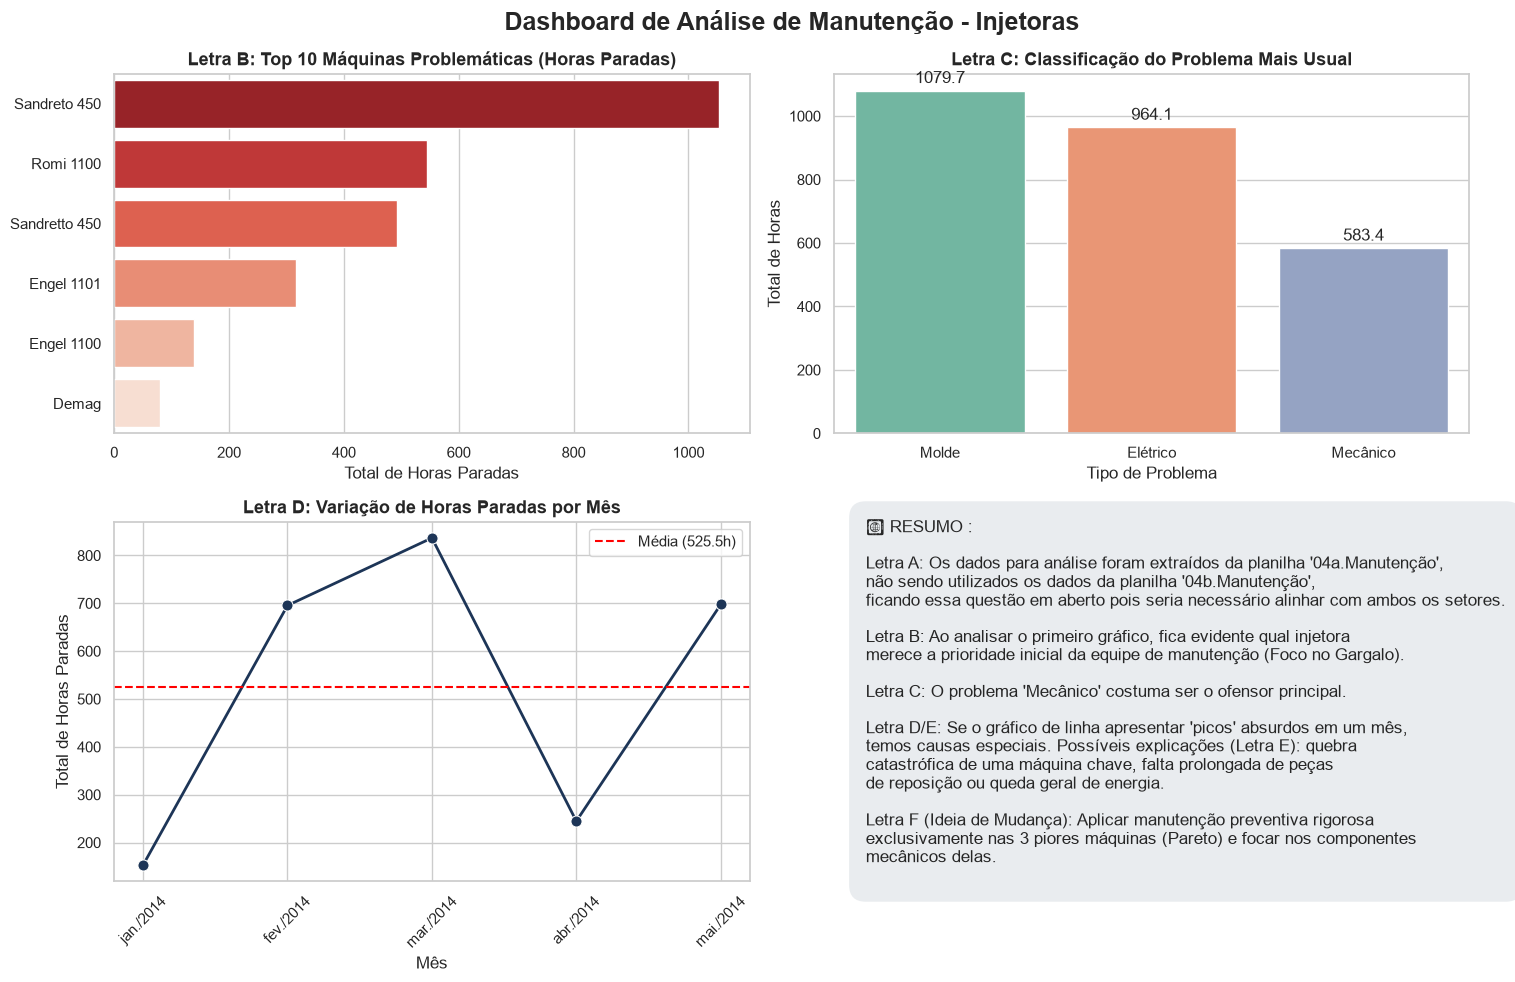

In [18]:
# Alterar possiveis valores NaN por zero para não estragar a soma
df = df.fillna(0)

# Agrupamos pela coluna 'Descrição' e somamos a coluna 'Tot'
df_maquinas = df.groupby('Descrição')['Tot'].sum().reset_index()
df_maquinas = df_maquinas.sort_values(by='Tot', ascending=False)
# Vamos pegar só as 10 piores máquinas para o gráfico não ficar espremido
top_10_maquinas = df_maquinas.head(10)

# Somamos o total geral de cada categoria de problema
total_eletrico = df['TotPE'].sum()
total_mecanico = df['TotMec'].sum()
total_molde = df['TotMol'].sum()

df_problemas = pd.DataFrame({
    'Tipo de Problema': ['Mecânico', 'Molde', 'Elétrico'],
    'Horas Paradas': [total_mecanico, total_molde, total_eletrico]
}).sort_values(by='Horas Paradas', ascending=False)

# Para manter a ordem cronológica correta (Janeiro, Fev, Mar...), o sort=False
# garante que o Pandas não vai organizar em ordem alfabética (que colocaria Abril antes de Janeiro)
df_tempo = df.groupby('Data', sort=False)['Tot'].sum().reset_index()
media_horas_mes = df_tempo['Tot'].mean()


sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Dashboard de Análise de Manutenção - Injetoras', fontsize=18, fontweight='bold')

# --- Gráfico 1 (Letra B): Pareto de Máquinas ---
sns.barplot(data=top_10_maquinas, x='Tot', y='Descrição', palette='Reds_r', ax=axes[0, 0])
axes[0, 0].set_title('Letra B: Top 10 Máquinas Problemáticas (Horas Paradas)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Total de Horas Paradas')
axes[0, 0].set_ylabel('')

# --- Gráfico 2 (Letra C): Tipos de Problemas ---
sns.barplot(data=df_problemas, x='Tipo de Problema', y='Horas Paradas', palette='Set2', ax=axes[0, 1])
axes[0, 1].set_title('Letra C: Classificação do Problema Mais Usual', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('Total de Horas')
# Adicionando o número em cima da barra
for container in axes[0, 1].containers:
    axes[0, 1].bar_label(container, fmt='%.1f', padding=3)

# --- Gráfico 3 (Letra D): Tendência ao longo do tempo ---
sns.lineplot(data=df_tempo, x='Data', y='Tot', marker='o', color='#1d3557', linewidth=2, markersize=8, ax=axes[1, 0])
axes[1, 0].axhline(media_horas_mes, color='red', linestyle='--', label=f'Média ({media_horas_mes:.1f}h)')
axes[1, 0].set_title('Letra D: Variação de Horas Paradas por Mês', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('Total de Horas Paradas')
axes[1, 0].set_xlabel('Mês')
axes[1, 0].tick_params(axis='x', rotation=45) # Inclina o texto dos meses para caber
axes[1, 0].legend()

# --- Painel de Conclusões (Letras E e F) ---
axes[1, 1].axis('off') 
conclusao_texto = """🎯 RESUMO :

Letra A: Os dados para análise foram extraídos da planilha '04a.Manutenção',
não sendo utilizados os dados da planilha '04b.Manutenção',
ficando essa questão em aberto pois seria necessário alinhar com ambos os setores.

Letra B: Ao analisar o primeiro gráfico, fica evidente qual injetora
merece a prioridade inicial da equipe de manutenção (Foco no Gargalo).

Letra C: O problema 'Mecânico' costuma ser o ofensor principal.

Letra D/E: Se o gráfico de linha apresentar 'picos' absurdos em um mês,
temos causas especiais. Possíveis explicações (Letra E): quebra
catastrófica de uma máquina chave, falta prolongada de peças
de reposição ou queda geral de energia.

Letra F (Ideia de Mudança): Aplicar manutenção preventiva rigorosa
exclusivamente nas 3 piores máquinas (Pareto) e focar nos componentes
mecânicos delas.
"""
axes[1, 1].text(0.05, 0.5, conclusao_texto, fontsize=12, verticalalignment='center', 
                bbox=dict(boxstyle="round,pad=1", facecolor="#e9ecef", edgecolor="none"))

plt.tight_layout()
plt.show()